<a href="https://colab.research.google.com/github/d16ago-lgtm/jit-tracing-hw3/blob/main/jax_jit_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JAX JIT Compilation Analysis

This notebook explores JIT compilation in JAX.  
We analyze compilation overhead, shape specialization, and operator fusion.

Experiments compare eager execution and JIT-compiled execution on GPU to understand
performance differences and compilation behavior.

## Part 1: Measuring JIT Compilation Overhead

In this experiment we measure the overhead of JIT compilation in JAX.

We execute a function that performs multiple elementwise operations on matrices
of different sizes.

We measure three cases:
- Eager execution (no JIT)
- First JIT call (includes compilation)
- Second JIT call (uses cached compiled code)

Testing matrix size: 100 x 100
Eager time: 0.642745s
JIT first time: 0.123674s
JIT second time: 0.000302s
Testing matrix size: 500 x 500
Eager time: 0.681107s
JIT first time: 0.142112s
JIT second time: 0.000253s
Testing matrix size: 1000 x 1000
Eager time: 0.472129s
JIT first time: 0.142092s
JIT second time: 0.000215s
Testing matrix size: 5000 x 5000
Eager time: 0.489974s
JIT first time: 0.146790s
JIT second time: 0.001552s


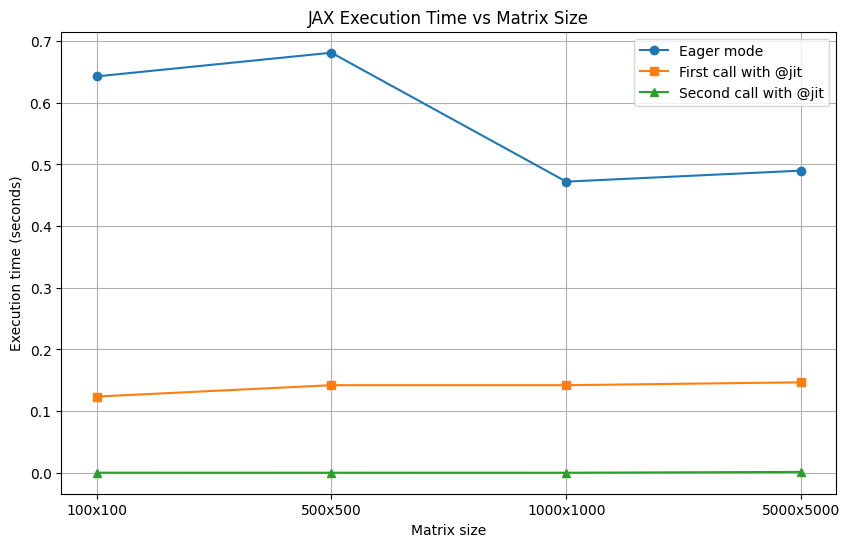

In [1]:
import jax
import jax.numpy as jnp
import time
import matplotlib.pyplot as plt

# Defining function with 10 elementwise operations
def f(x):
    a = jnp.sin(x)
    b = jnp.cos(a)
    c = jnp.exp(b)
    d = jnp.log(c + 1)
    e = jnp.square(d)
    f1 = jnp.sqrt(e + 1)
    g = jnp.tanh(f1)
    h = jnp.abs(g)
    i = h + 2
    y = i * 3
    return y

# JIT version
f_jit = jax.jit(f)

# Matrix sizes to test
sizes = [100, 500, 1000, 5000]

eager_times = []
jit_first_times = []
jit_second_times = []

# Run timing tests
for n in sizes:
    print("Testing matrix size:", n, "x", n)
    x = jnp.ones((n, n))

    # Eager mode timing
    start = time.time()
    y_eager = f(x)
    y_eager.block_until_ready()
    eager_time = time.time() - start
    print(f"Eager time: {eager_time:.6f}s")
    eager_times.append(eager_time)

    # First JIT call: includes compilation
    start = time.time()
    jit_first = f_jit(x)
    jit_first.block_until_ready()
    jit_first_time = time.time() - start
    print(f"JIT first time: {jit_first_time:.6f}s")
    jit_first_times.append(jit_first_time)

    # Second JIT call: uses compiled version
    start = time.time()
    jit_second = f_jit(x)
    jit_second.block_until_ready()
    jit_second_time = time.time() - start
    print(f"JIT second time: {jit_second_time:.6f}s")
    jit_second_times.append(jit_second_time)

# Creating the plot
labels = [f"{n}x{n}" for n in sizes]

plt.figure(figsize=(10, 6))
plt.plot(labels, eager_times, marker='o', label='Eager mode')
plt.plot(labels, jit_first_times, marker='s', label='First call with @jit')
plt.plot(labels, jit_second_times, marker='^', label='Second call with @jit')

plt.xlabel("Matrix size")
plt.ylabel("Execution time (seconds)")
plt.title("JAX Execution Time vs Matrix Size")
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Shape Specialization

JAX specializes compiled functions for specific input shapes.

When a JIT-compiled function receives a new input shape,
JAX retraces the function and compiles a new version.

This experiment tests how different matrix shapes affect retracing behavior.

Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=f
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape: (100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = jit[
      name=f
      jaxpr={ lambda ; a:f32[100,200]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 200.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=f
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }
Shape: (200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = jit[
      name=f
      jaxpr={ lambda ; a:f32[200,100]. let
          c:f32[200] = reduce_sum[axes=(1,)] a
          b:f32[200] = div c 100.0:f32[]
        in (b,) }
    ] a


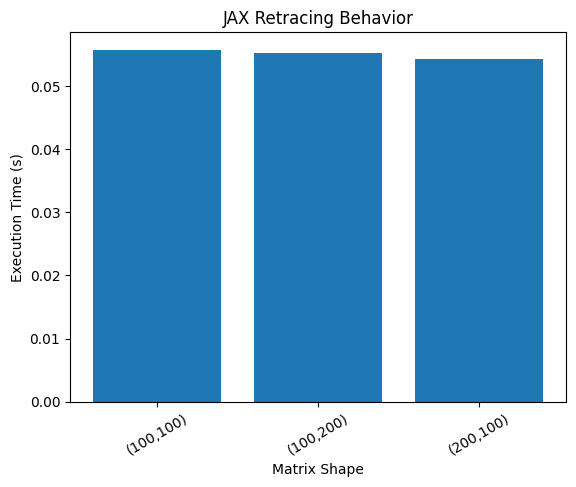

In [2]:
import jax
import jax.numpy as jnp
import time
import matplotlib.pyplot as plt

@jax.jit
def f(x):
    # Compute mean of each row
    return jnp.mean(x, axis=1)

#First call: traces for shape (100,100)
x1 = jnp.ones((100,100))
start = time.time()
y1 = f(x1)
y1.block_until_ready()
t1 = time.time() - start

print("Shape:", x1.shape)
print(jax.make_jaxpr(f)(x1))

#New shape: retraces for (100,200)
x2 = jnp.ones((100,200))
start = time.time()
y2 = f(x2)
y2.block_until_ready()
t2 = time.time() - start

print("Shape:", x2.shape)
print(jax.make_jaxpr(f)(x2))

# Same shape again: uses cached compilation
x3 = jnp.ones((100,100))
start = time.time()
y3 = f(x3)
y3.block_until_ready()
t3 = time.time() - start

print("Shape:", x3.shape)
print(jax.make_jaxpr(f)(x3))

#New shape again: retraces for (200,100)
x4 = jnp.ones((200,100))
start = time.time()
y4 = f(x4)
y4.block_until_ready()
t4 = time.time() - start

print("Shape:", x4.shape)
print(jax.make_jaxpr(f)(x4))


#Plot execution times
times = [t1, t2, t3, t4]
print(times)
labels = ["(100,100)", "(100,200)", "(100,100)", "(200,100)"]

plt.bar(labels, times)
plt.xticks(rotation=30)
plt.xlabel("Matrix Shape")
plt.ylabel("Execution Time (s)")
plt.title("JAX Retracing Behavior")
plt.show()

## Part 3: Operator Fusion

Operator fusion combines multiple elementwise operations into a single GPU kernel.

This reduces kernel launch overhead and memory traffic.

We compare two implementations:
- Version A: eager execution using a loop
- Version B: JIT compiled version

In [3]:
import torch
import time
from torch.profiler import profile, ProfilerActivity
from functools import reduce

device = "cuda" if torch.cuda.is_available() else "cpu"

# Version A
def f_eager(x):
    result = torch.zeros_like(x)

    s = x
    c = x

    for _ in range(100):
        s = torch.sin(s)          # separate kernel
        c = torch.cos(c)          # separate kernel
        result = result + s + c   # separate kernel(s)

    return result

# Version B
@torch.compile
def f_jit(x):
    return sum(
        reduce(lambda v, _: torch.sin(v), range(i), x) +
        reduce(lambda v, _: torch.cos(v), range(i), x)
        for i in range(1, 101)
    )

x = torch.ones((5000, 5000), device=device)

# Warmup
for _ in range(3):
    f_eager(x)
    f_jit(x)

if device == "cuda":
    torch.cuda.synchronize()

# Eager timing
start = time.time()
y1 = f_eager(x)
if device == "cuda":
    torch.cuda.synchronize()
print(f"Eager time: {time.time() - start:.3f}s")

# JIT timing
start = time.time()
y2 = f_jit(x)
if device == "cuda":
    torch.cuda.synchronize()
print(f"JIT time: {time.time() - start:.3f}s")

#Running profiler for eager version
activities = [ProfilerActivity.CPU]
if device == "cuda":
    activities.append(ProfilerActivity.CUDA)

print("\nEager profiler:")

with profile(activities=activities) as prof:
    f_eager(x)

print(prof.key_averages().table(
    sort_by="cuda_time_total" if device == "cuda" else "cpu_time_total",
    row_limit=10
))

#JIT profiler
print("\nJIT profiler:")

with profile(activities=activities) as prof:
    f_jit(x)

print(prof.key_averages().table(
    sort_by="cuda_time_total" if device == "cuda" else "cpu_time_total",
    row_limit=10
))

Eager time: 0.418s
JIT time: 0.402s

Eager profiler:


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::add         0.56%       2.341ms         1.02%       4.266ms      21.329us     246.752ms        59.17%     246.752ms       1.234ms           200  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     246.752ms        59.17%     246.752ms       1.234ms           200  
         